In [2]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
from plot_utils import plot_straddle_payoff,  plot_call_butterfly_payoff

from pathlib import Path
BASE_DIR = Path.cwd().parent
file_path = BASE_DIR / "vrp_results"

# NOTE: we are not going to use option_reader for two reasons
# 1. we are validating the whole backtest, including the option reader
# 2. I don't want to move this code because I am stubborn, and I can't import from the parent directory
def get_option_row(
    ticker : str,
    trade_date : str,
    expiry : str,
    strike : float
) -> pd.Series:
    '''
    Brand new function for validation
    '''

    # convert trade_date and expiry to datetime
    trade_date = pd.to_datetime(trade_date)
    expiry = pd.to_datetime(expiry)

    # get path
    y = trade_date.year
    ymd = trade_date.strftime("%Y%m%d")
    option_today_path = BASE_DIR / "data" / str(y) / f"ORATS_SMV_Strikes_{ymd}.zip"
    assert option_today_path.exists(), f"Option data for {trade_date} does not exist at {option_today_path}"

    dtypes = {
        "ticker": "string",
        "cOpra": "string",
        "pOpra": "string",
        "stkPx": "float32",
        "yte": "float32",
        "strike": "float32",
        "cVolu": "Int32",
        "pVolu": "Int32",
        "cValue": "float32",
        "pValue": "float32",
        "smoothSmvVol": "float32",
        "delta": "float32",
    }
    cols = ["ticker", "cOpra", "pOpra", "stkPx", "trade_date", "expirDate", "yte", "strike","cVolu", "pVolu", "cValue", "pValue", "smoothSmvVol", "delta"]

    opt = pd.read_csv(
        option_today_path,
        compression="zip",
        usecols=cols,
        dtype=dtypes
    )
    opt = opt.loc[opt["ticker"].eq(ticker)]

    opt = opt.rename(columns={"smoothSmvVol": "vol",})
    opt["trade_date"] = pd.to_datetime(opt["trade_date"])
    opt["expirDate"]  = pd.to_datetime(opt["expirDate"])
    opt["dte"] = (opt["expirDate"] - opt["trade_date"]).dt.days.astype("float32")

    row = opt.loc[opt["expirDate"].eq(expiry) & opt["strike"].eq(strike)]

    if row.empty:
        print(opt.loc[opt["expirDate"].eq(expiry)])
        raise ValueError(f"No option data found for {ticker} {expiry} {strike} at {trade_date}")

    return row.iloc[0]

# Validate Straddle
first one used for thesis

second one for testing

Short StraddlePnL = 11.89 + -23.78 = -11.89
Underlying price at entry: 109.89, at exit: 87.61


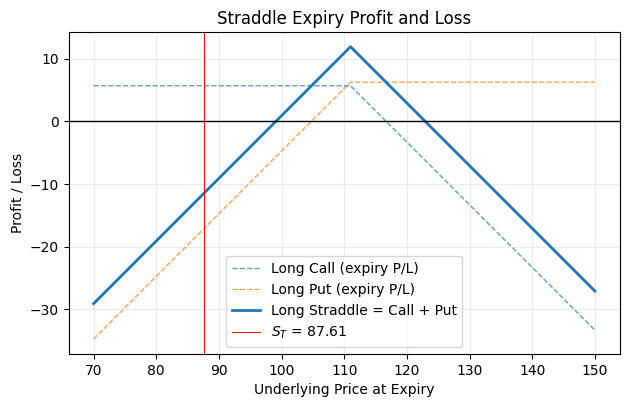

,ticker,cOpra,pOpra,stkPx,expirDate,yte,strike,cVolu,pVolu,cValue,pValue,vol,delta,trade_date,dte
396378,MU,MU240830C00111000,MU240830P00111000,109.889999,2024-08-30,0.08219,111.0,40,20,5.66,6.230000,0.466134,0.512505,2024-07-31,30.0
402906,MU,MU240830C00111000,MU240830P00111000,87.610001,2024-08-30,0.06301,111.0,250,8,0.31,23.469999,0.572856,0.061184,2024-08-07,23.0


In [3]:
ticker = "MU"
open_date = "2024-07-31"
close_date = "2024-08-07"
expiry = "2024-08-30"
strike = 111

row_entry = get_option_row(ticker, open_date, expiry, strike)
row_exit = get_option_row(ticker, close_date, expiry, strike)
entry_cashflow = row_entry["cValue"] + row_entry["pValue"]
exit_cashflow = - row_exit["cValue"] - row_exit["pValue"]

print(f"Short StraddlePnL = {entry_cashflow:.2f} + {exit_cashflow:.2f} = {exit_cashflow + entry_cashflow:.2f}")
print(f"Underlying price at entry: {row_entry['stkPx']:.2f}, at exit: {row_exit['stkPx']:.2f}")


file_path = BASE_DIR / "tabs_and_figs"
plot_straddle_payoff(
    strike,
    row_entry["cValue"],
    row_entry["pValue"],
    S_T=row_exit['stkPx'],
    xlim=(70, 150),
    path = file_path / 'ch2_straddle_pnl_MU.png',
    short = True
)

df = pd.DataFrame([row_entry, row_exit])
df

In [4]:
ticker = "USO"
open_date = "2020-04-23"
close_date = "2020-05-22"
expiry = "2020-05-22"
strike = 3

row_entry = get_option_row(ticker, open_date, expiry, strike)
print(f"Entry:")
print(row_entry)
print()
entry_cashflow = row_entry["cValue"] + row_entry["pValue"]

row_exit = get_option_row(ticker, close_date, expiry, strike)
print(f"Exit:")
print(row_exit)
print()
exit_cashflow = - row_exit["cValue"] - row_exit["pValue"]

row_exit = get_option_row(ticker, close_date, expiry, strike*10)
print(f"Exit:")
print(row_exit)
print()
exit_cashflow = - row_exit["cValue"] - row_exit["pValue"]

print(f"Short StraddlePnL = {entry_cashflow:.2f} + {exit_cashflow:.2f} = {exit_cashflow + entry_cashflow:.2f}")
print(f"Underlying price at entry: {row_entry['stkPx']:.2f}, at exit: {row_exit['stkPx']:.2f}")

Entry:
ticker                        USO
cOpra          USO200522C00003000
pOpra          USO200522P00003000
stkPx                        2.62
expirDate     2020-05-22 00:00:00
yte                       0.07945
strike                        3.0
cVolu                        2105
pVolu                        1876
cValue                       0.26
pValue                       0.64
vol                      1.338464
delta                    0.432687
trade_date    2020-04-23 00:00:00
dte                          29.0
Name: 510774, dtype: object

Exit:
ticker                        USO
cOpra          USO200522C00003000
pOpra          USO200522P00003000
stkPx                   25.540001
expirDate     2020-05-22 00:00:00
yte                           0.0
strike                        3.0
cVolu                         656
pVolu                          45
cValue                  22.540001
pValue                        0.0
vol                      0.438232
delta                         1.0
trade_

# Validate Butterfly

In [ ]:
ticker = "GME"
open_date = "2021-02-08"
close_date = "2021-03-12"
expiry = close_date
strike_15d = 325
strike_50d = 85
strike_85d = 35

row_entry_15d = get_option_row(ticker, open_date, expiry, strike_15d)
row_entry_50d = get_option_row(ticker, open_date, expiry, strike_50d)
row_entry_85d = get_option_row(ticker, open_date, expiry, strike_85d)

row_exit_15d = get_option_row(ticker, close_date, expiry, strike_15d)
row_exit_50d = get_option_row(ticker, close_date, expiry, strike_50d)
row_exit_85d = get_option_row(ticker, close_date, expiry, strike_85d)

print(f"Entry: - {row_entry_15d['cValue']:.2f} + 2 * {row_entry_50d['cValue']:.2f} - {row_entry_85d['cValue']:.2f} = {(- row_entry_15d['cValue'] + 2 * row_entry_50d['cValue'] - row_entry_85d['cValue']):.2f}")
print(f"Exit: + {row_exit_15d['cValue']:.2f} - 2 * {row_exit_50d['cValue']:.2f} + {row_exit_85d['cValue']:.2f} = {( + row_exit_15d['cValue'] - 2 * row_exit_50d['cValue'] + row_exit_85d['cValue']):.2f}")
print(f"Long Butterfly PnL: {( + row_exit_15d['cValue'] - 2 * row_exit_50d['cValue'] + row_exit_85d['cValue']) + (- row_entry_15d['cValue'] + 2 * row_entry_50d['cValue'] - row_entry_85d['cValue']):.2f}")
print(f"Underlying price at entry: {row_entry_15d['stkPx']:.2f}, at exit: {row_exit_15d['stkPx']:.2f}")

df = pd.DataFrame([row_entry_15d, row_entry_50d, row_entry_85d, row_exit_15d, row_exit_50d, row_exit_85d])
df

file_path = BASE_DIR / "tabs_and_figs"
plot_call_butterfly_payoff(
    strike_15d,
    strike_50d,
    strike_85d,
    row_entry_15d["cValue"],
    row_entry_50d["cValue"],
    row_entry_85d["cValue"],
    S_T = row_exit_50d['stkPx'],
    xlim=(20, 350),
    path = file_path / 'ch2_butterfly_pnl_GME.png',
)

Entry: - 3.54 + 2 * 13.00 - 29.29 = -6.83
Exit: + 0.00 - 2 * 186.38 + 236.38 = -136.38
Long Butterfly PnL: -143.21
Underlying price at entry: 58.51, at exit: 271.38


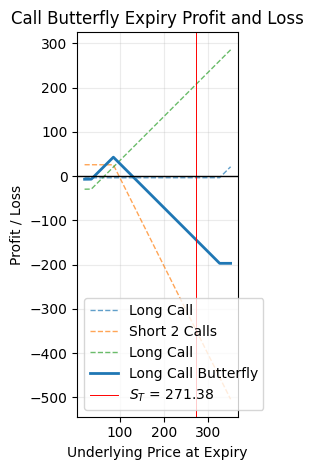

In [5]:
ticker = "GME"
open_date = "2021-02-08"
close_date = "2021-03-12"
expiry = close_date
strike_15d = 325
strike_50d = 85
strike_85d = 35

row_entry_15d = get_option_row(ticker, open_date, expiry, strike_15d)
row_entry_50d = get_option_row(ticker, open_date, expiry, strike_50d)
row_entry_85d = get_option_row(ticker, open_date, expiry, strike_85d)

row_exit_15d = get_option_row(ticker, close_date, expiry, strike_15d)
row_exit_50d = get_option_row(ticker, close_date, expiry, strike_50d)
row_exit_85d = get_option_row(ticker, close_date, expiry, strike_85d)

print(f"Entry: - {row_entry_15d['cValue']:.2f} + 2 * {row_entry_50d['cValue']:.2f} - {row_entry_85d['cValue']:.2f} = {(- row_entry_15d['cValue'] + 2 * row_entry_50d['cValue'] - row_entry_85d['cValue']):.2f}")
print(f"Exit: + {row_exit_15d['cValue']:.2f} - 2 * {row_exit_50d['cValue']:.2f} + {row_exit_85d['cValue']:.2f} = {( + row_exit_15d['cValue'] - 2 * row_exit_50d['cValue'] + row_exit_85d['cValue']):.2f}")
print(f"Long Butterfly PnL: {( + row_exit_15d['cValue'] - 2 * row_exit_50d['cValue'] + row_exit_85d['cValue']) + (- row_entry_15d['cValue'] + 2 * row_entry_50d['cValue'] - row_entry_85d['cValue']):.2f}")
print(f"Underlying price at entry: {row_entry_15d['stkPx']:.2f}, at exit: {row_exit_15d['stkPx']:.2f}")

df = pd.DataFrame([row_entry_15d, row_entry_50d, row_entry_85d, row_exit_15d, row_exit_50d, row_exit_85d])
df

file_path = BASE_DIR / "tabs_and_figs"
plot_call_butterfly_payoff(
    strike_15d,
    strike_50d,
    strike_85d,
    row_entry_15d["cValue"],
    row_entry_50d["cValue"],
    row_entry_85d["cValue"],
    S_T = row_exit_50d['stkPx'],
    xlim=(20, 350),
    path = file_path / 'ch2_butterfly_pnl_GME.png',
)

# Validate Call Calendar
archivied. we not gonna do calendar for thesis

In [ ]:
ticker = "ZM"
open_date = "2022-12-19"
close_date = "2023-01-20"
near_expiry = "2023-01-20"
far_expiry = "2023-02-17"

near_strike = 70
far_strike = 70

entry_near = get_option_row(ticker, open_date, near_expiry, near_strike)
entry_far = get_option_row(ticker, open_date, far_expiry, far_strike)
exit_near = get_option_row(ticker, close_date, near_expiry, near_strike)
exit_far = get_option_row(ticker, close_date, far_expiry, far_strike)


# call calendar entry cashflow: short near call, long far call
entry_cashflow = + entry_near["cValue"] - entry_far["cValue"]
exit_cashflow = - exit_near["cValue"] + exit_far["cValue"]

print(f"Long Call Calendar PnL = {entry_cashflow:.2f} + {exit_cashflow:.2f} = {exit_cashflow + entry_cashflow:.2f}")
print(f"Underlying price at entry: {entry_near['stkPx']:.2f}, at exit: {exit_near['stkPx']:.2f}")

df = pd.DataFrame([entry_near, entry_far, exit_near, exit_far])
df

Long Call Calendar PnL = 0.03 + 3.50 = 3.53
Underlying price at entry: 69.02, at exit: 69.48


,ticker,cOpra,pOpra,stkPx,expirDate,yte,strike,cVolu,pVolu,cValue,pValue,vol,delta,trade_date,dte
666070,ZM,ZM230120C00070000,ZM230120P00070000,69.019997,2023-01-20,0.08767,70.0,182,101,0.03,4.51,0.437244,0.493934,2022-12-19,32.0
666204,ZM,ZM230217C00070000,ZM230217P00070000,69.019997,2023-02-17,0.16438,70.0,255,47,0.00,6.37,0.544018,0.531238,2022-12-19,60.0
762940,ZM,ZM230120C00070000,ZM230120P00070000,69.480003,2023-01-20,0.00000,70.0,3376,169,0.04,0.57,0.616417,0.143934,2023-01-20,0.0
763160,ZM,ZM230217C00070000,ZM230217P00070000,69.480003,2023-02-17,0.07671,70.0,1046,81,3.54,3.83,0.474121,0.514774,2023-01-20,28.0


: 